In [12]:
#必要なモジュールのインポート
import boto3 # AWSのサービスを利用するときに必須
import json # json形式のデータを処理する
from PIL import Image # pillow の Image モジュール 画像処理に使用する

In [13]:
# コレクションIDを入力
collection_id = input("文字列を入力してください:")


文字列を入力してください: MyCollection


# サービスクライアントを作成

In [14]:
rekognition = boto3.client('rekognition')

# コレクションの作成

In [15]:
# コレクションを作成する
result = rekognition.create_collection(CollectionId=collection_id)

# 結果のjsonを整形して表示
print(json.dumps(result, indent=4))

{
    "StatusCode": 200,
    "CollectionArn": "aws:rekognition:us-east-1:546943788404:collection/MyCollection",
    "FaceModelVersion": "7.0",
    "ResponseMetadata": {
        "RequestId": "fde43b83-aee0-4d81-931d-80aaebeaed37",
        "HTTPStatusCode": 200,
        "HTTPHeaders": {
            "x-amzn-requestid": "fde43b83-aee0-4d81-931d-80aaebeaed37",
            "content-type": "application/x-amz-json-1.1",
            "content-length": "124",
            "date": "Fri, 06 Mar 2026 08:00:12 GMT"
        },
        "RetryAttempts": 0
    }
}


# コレクションの表示

In [16]:
print('コレクションの一覧')
# コレクションの一覧を取得
result = rekognition.list_collections()

# 結果のjsonを整形して表示
print(json.dumps(result, indent=4))

print('登録されている顔の一覧')
# 登録された顔の一覧を取得
result = rekognition.list_faces(CollectionId=collection_id)
# 登録された顔の一覧を表示
print(json.dumps(result, indent=4))

コレクションの一覧
{
    "CollectionIds": [
        "MyCollection",
        "demo120402-mashiko"
    ],
    "FaceModelVersions": [
        "7.0",
        "7.0"
    ],
    "ResponseMetadata": {
        "RequestId": "068eb1a5-48f5-48a0-91ca-bce738c31fbb",
        "HTTPStatusCode": 200,
        "HTTPHeaders": {
            "x-amzn-requestid": "068eb1a5-48f5-48a0-91ca-bce738c31fbb",
            "content-type": "application/x-amz-json-1.1",
            "content-length": "89",
            "date": "Fri, 06 Mar 2026 08:00:13 GMT"
        },
        "RetryAttempts": 0
    }
}
登録されている顔の一覧
{
    "Faces": [],
    "FaceModelVersion": "7.0",
    "ResponseMetadata": {
        "RequestId": "e308b728-350b-4d42-9e8a-25456ba70058",
        "HTTPStatusCode": 200,
        "HTTPHeaders": {
            "x-amzn-requestid": "e308b728-350b-4d42-9e8a-25456ba70058",
            "content-type": "application/x-amz-json-1.1",
            "content-length": "37",
            "date": "Fri, 06 Mar 2026 08:00:13 GMT"
        },
 

# コレクションに顔を登録する

In [17]:
# 登録する画像のリスト
# images_regist = ['richard.jpg', 'richard2.jpg']


# ユーザーに画像ファイル名を入力させる（カンマ区切り）
input_files = input("登録したい画像ファイル名をカンマ区切りで入力してください: ")
 
# 入力をリストに変換（空白を除去）
images_regist = [f.strip() for f in input_files.split(',')]
 
print("登録する画像:", images_regist)

登録したい画像ファイル名をカンマ区切りで入力してください:  sharing_01.jpg


登録する画像: ['sharing_01.jpg']


In [18]:
# 顔の登録
print('index_faces:')
print(len(images_regist))

# 指定された画像ファイルの分だけ繰り返す
for path in images_regist:
    # 画像ファイルをオープン
    with open(path, 'rb') as file:
        # 画像内の顔を登録
        result = rekognition.index_faces(
            CollectionId=collection_id,
            Image={'Bytes': file.read()})

    # 顔の登録結果を表示
    print(json.dumps(result, indent=4))

index_faces:
1
{
    "FaceRecords": [
        {
            "Face": {
                "FaceId": "ad749a7f-e07c-48ed-b114-47fe81c15ece",
                "BoundingBox": {
                    "Width": 0.049764346331357956,
                    "Height": 0.1336122453212738,
                    "Left": 0.7468746304512024,
                    "Top": 0.22909905016422272
                },
                "ImageId": "c0da4c11-9dc5-3192-8d3a-7132cfa488fa",
                "Confidence": 99.99463653564453
            },
            "FaceDetail": {
                "BoundingBox": {
                    "Width": 0.049764346331357956,
                    "Height": 0.1336122453212738,
                    "Left": 0.7468746304512024,
                    "Top": 0.22909905016422272
                },
                "Landmarks": [
                    {
                        "Type": "eyeLeft",
                        "X": 0.7580944299697876,
                        "Y": 0.282715767621994
                  

# 画像に写っている顔が、コレクションの中に存在するかをチェック

In [27]:
file_in = 'sharing_01.jpg' # コレクションに存在するかチェックする画像
file_out = 'detected.jpg' # 見つかった顔の部分だけを出力する画像ファイル名
# 画像ファイルを開く
with open(file_in, 'rb') as file:
    # 画像内の顔をコレクションから探す
    result = rekognition.index_faces(
        CollectionId=collection_id,
        Image={'Bytes': file.read()})
# 結果を整形して表示
print(json.dumps(result, indent=4))

{
    "FaceRecords": [
        {
            "Face": {
                "FaceId": "ad749a7f-e07c-48ed-b114-47fe81c15ece",
                "BoundingBox": {
                    "Width": 0.049764346331357956,
                    "Height": 0.1336122453212738,
                    "Left": 0.7468746304512024,
                    "Top": 0.22909905016422272
                },
                "ImageId": "c0da4c11-9dc5-3192-8d3a-7132cfa488fa",
                "Confidence": 99.99463653564453
            },
            "FaceDetail": {
                "BoundingBox": {
                    "Width": 0.049764346331357956,
                    "Height": 0.1336122453212738,
                    "Left": 0.7468746304512024,
                    "Top": 0.22909905016422272
                },
                "Landmarks": [
                    {
                        "Type": "eyeLeft",
                        "X": 0.7580944299697876,
                        "Y": 0.282715767621994
                    },
          

## 見つかった顔の部分だけの画像を作る

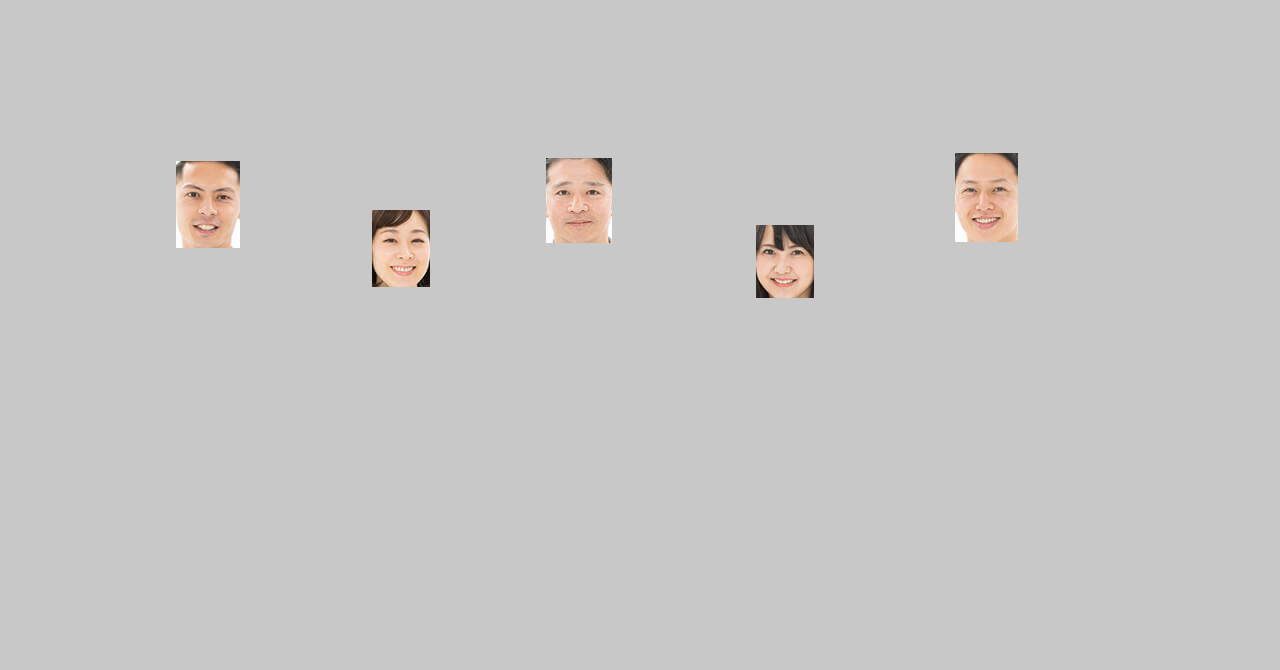

In [28]:
# 入力画像のファイルを読み込む
image_in = Image.open(file_in)

# 画像サイズを取得
w, h = image_in.size

# Imageオブジェクトを生成
image_out = Image.new('RGB', (w, h), (200, 200, 200))


# FaceRecords から全顔の BoundingBox を使って切り出し＆貼り付け
face_records = result.get('FaceRecords', [])
if not face_records:
    print("顔が検出・登録されませんでした。")
else:
    for rec in face_records:
        box = rec['FaceDetail']['BoundingBox']  # ← index_faces ではここから取る
        left   = int(box['Left']   * w)
        top    = int(box['Top']    * h)
        right  = left + int(box['Width']  * w)
        bottom = top  + int(box['Height'] * h)

        # 画像境界でクリップ（安全策）
        left   = max(0, min(left,   w-1))
        top    = max(0, min(top,    h-1))
        right  = max(left+1, min(right,  w))
        bottom = max(top+1,  min(bottom, h))

        # 入力画像から顔領域を切り出して、そのまま同位置に貼り付け
        face_crop = image_in.crop((left, top, right, bottom))
        image_out.paste(face_crop, (left, top))

# 保存・表示
image_out.save(file_out)
image_out.show()


# コレクションの削除

In [29]:
result = rekognition.delete_collection(CollectionId=collection_id)
print(json.dumps(result, indent=4))

{
    "StatusCode": 200,
    "ResponseMetadata": {
        "RequestId": "7f95c57a-8133-4c19-94f9-a8e9ea7c483a",
        "HTTPStatusCode": 200,
        "HTTPHeaders": {
            "x-amzn-requestid": "7f95c57a-8133-4c19-94f9-a8e9ea7c483a",
            "content-type": "application/x-amz-json-1.1",
            "content-length": "18",
            "date": "Fri, 06 Mar 2026 08:25:05 GMT"
        },
        "RetryAttempts": 0
    }
}
